<a href="https://colab.research.google.com/github/rkaran112/ML_Lab-2547241/blob/main/ML_2547241_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: KNN Classification on the Breast Cancer Dataset, with Comparison to Regression Metrics (Lab 3)

**Aim:** Implement KNN classification on the Breast Cancer Wisconsin (Diagnostic) dataset, analyze performance using train-test splits, heuristic K selection, cross-validation, ROC-AUC and classification metrics, and compare classification metrics with the regression metrics studied in Lab 3.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Dataset (`sklearn.datasets.load_breast_cancer`) — 569 samples, 30 numerical features, target 0 = Malignant, 1 = Benign.

## Task 1: Data Preparation
Load the dataset, convert to a DataFrame, check structure/missing values/duplicates, and apply `StandardScaler`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay,
                              mean_absolute_error, mean_squared_error, r2_score)

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Shape:", df.shape)
print("\nTarget classes: 0 = malignant, 1 = benign")
print(df['target'].value_counts())
print("\nMissing values total:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.head(3)

Shape: (569, 31)

Target classes: 0 = malignant, 1 = benign
target
1    357
0    212
Name: count, dtype: int64

Missing values total: 0
Duplicate rows: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [ ]:
X = df.drop(columns=['target']).values
y = df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling - mean radius: mean=%.3f std=%.3f" % (X[:,0].mean(), X[:,0].std()))
print("After  scaling - mean radius: mean=%.3f std=%.3f" % (X_scaled[:,0].mean(), X_scaled[:,0].std()))

Before scaling - mean radius: mean=14.127 std=3.521
After  scaling - mean radius: mean=-0.000 std=1.000


**Why feature scaling is required:** KNN classifies using Euclidean/Manhattan distance between feature vectors. Features here are on very different scales (e.g. `mean area` up to ~2500 vs `mean smoothness` ~0.05–0.16). Without scaling, large-magnitude features dominate the distance calculation, silencing smaller-magnitude but potentially more informative features. `StandardScaler` puts every feature at zero mean / unit variance so each contributes fairly.

## Task 2: Train-Test Split Analysis
Split into 80:20, 70:30 and 90:10 and compare performance using each split's own heuristic K.

In [ ]:
results = {}
for test_size in [0.20, 0.30, 0.10]:
    Xtr, Xte, ytr, yte = train_test_split(X_scaled, y, test_size=test_size, random_state=42, stratify=y)
    k = int(round(np.sqrt(len(Xtr))))
    if k % 2 == 0:
        k += 1
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(Xtr, ytr)
    acc = accuracy_score(yte, model.predict(Xte))
    ratio = f"{int((1-test_size)*100)}:{int(test_size*100)}"
    results[ratio] = (len(Xtr), len(Xte), k, acc)
    print(f"Split {ratio:6s} -> train={len(Xtr):3d}, test={len(Xte):3d}, heuristic K={k}, accuracy={acc:.4f}")

Split 80:20  -> train=455, test=114, heuristic K=21, accuracy=0.9561
Split 70:30  -> train=398, test=171, heuristic K=21, accuracy=0.9474
Split 90:10  -> train=512, test= 57, heuristic K=23, accuracy=0.9825


**Analysis:** Accuracy varies modestly (94.7%–98.3%) across splits. The 90:10 split shows the highest accuracy, but its test set (57 samples) is small, giving a higher-variance, less reliable estimate. The 80:20 split balances training volume (stable neighbour estimation) against test set size (a statistically meaningful accuracy estimate). As the training fraction shrinks (70:30), the model sees fewer examples per class and generalization weakens slightly — split ratio affects both model stability and the reliability of the reported metric.

## Task 3: KNN Model with Heuristic K Selection
### 3.1 Heuristic Method for K Selection
Compute the initial K using K = √n, where n = number of training samples (80:20 split).

In [ ]:
Xtr, Xte, ytr, yte = train_test_split(X_scaled, y, test_size=0.20, random_state=42, stratify=y)
n = len(Xtr)
k_heuristic = int(round(np.sqrt(n)))
if k_heuristic % 2 == 0:
    k_heuristic += 1
print("n (train samples) =", n)
print("Heuristic K = sqrt(n) =", np.sqrt(n), "-> rounded/odd K =", k_heuristic)

n (train samples) = 455
Heuristic K = sqrt(n) = 21.330729007701542 -> rounded/odd K = 21


### 3.2 Model Training with K ± 5 Sweep
Train KNN using the heuristic K, experiment with nearby K values, and plot accuracy vs K.

In [ ]:
k_range = range(max(1, k_heuristic - 5), k_heuristic + 6)
accs = []
for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(Xtr, ytr)
    acc = accuracy_score(yte, model.predict(Xte))
    accs.append(acc)
    print(f"K={k:2d} -> accuracy={acc:.4f}")

best_idx = int(np.argmax(accs))
best_k = list(k_range)[best_idx]
print(f"\nBest K in heuristic neighborhood: K={best_k}, accuracy={accs[best_idx]:.4f}")

K=16 -> accuracy=0.9737
K=17 -> accuracy=0.9737
K=18 -> accuracy=0.9825
K=19 -> accuracy=0.9737
K=20 -> accuracy=0.9649
K=21 -> accuracy=0.9561
K=22 -> accuracy=0.9561
K=23 -> accuracy=0.9649
K=24 -> accuracy=0.9561
K=25 -> accuracy=0.9649
K=26 -> accuracy=0.9561

Best K in heuristic neighborhood: K=18, accuracy=0.9825


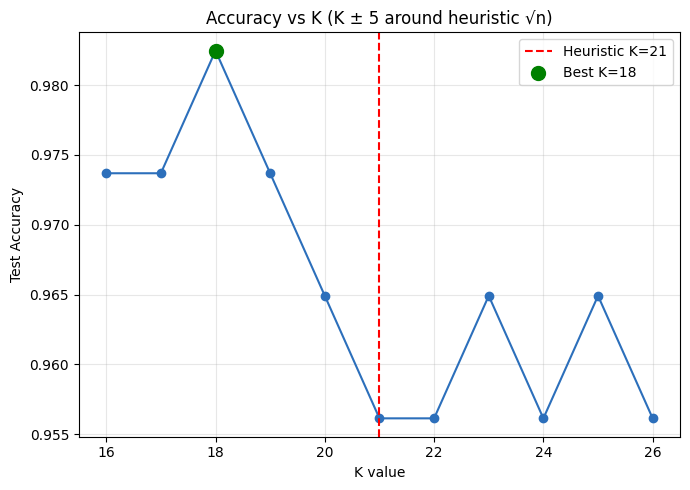

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(list(k_range), accs, marker='o', color='#2c6fbb')
plt.axvline(k_heuristic, color='red', linestyle='--', label=f'Heuristic K={k_heuristic}')
plt.scatter([best_k],[accs[best_idx]], color='green', s=100, zorder=5, label=f'Best K={best_k}')
plt.xlabel('K value'); plt.ylabel('Test Accuracy')
plt.title('Accuracy vs K (K \u00b1 5 around heuristic \u221an)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

**Observation:** Although the heuristic gives K=21, the empirical best in this neighbourhood is K=18. Accuracy trends downward as K grows past 18 in this range, then fluctuates — the model is near the bias-variance sweet spot around K=16–19.

### 3.3 Distance Metrics and Decision Boundary Mapping

**Euclidean Distance:** straight-line distance, d(x,y) = sqrt(Σ(xi − yi)²). Default metric for KNN; works well when features are continuous, similarly scaled, and 'closeness' is naturally geometric (as in this scaled feature space). Sensitive to outliers and high dimensionality.

**Manhattan Distance:** sum of absolute differences, d(x,y) = Σ|xi − yi|. Preferred when data is high-dimensional, contains outliers, or movement is axis-aligned (grid-like data). Generally more robust than Euclidean distance in high-dimensional/noisy feature spaces.

To visualize decision boundaries in 2D, project the 30 features onto their first 2 principal components (PCA) and retrain KNN for K = 1, 5, 10, 20.

Explained variance ratio (2 PCs): [0.44272026 0.18971182] sum= 0.6324320765155943


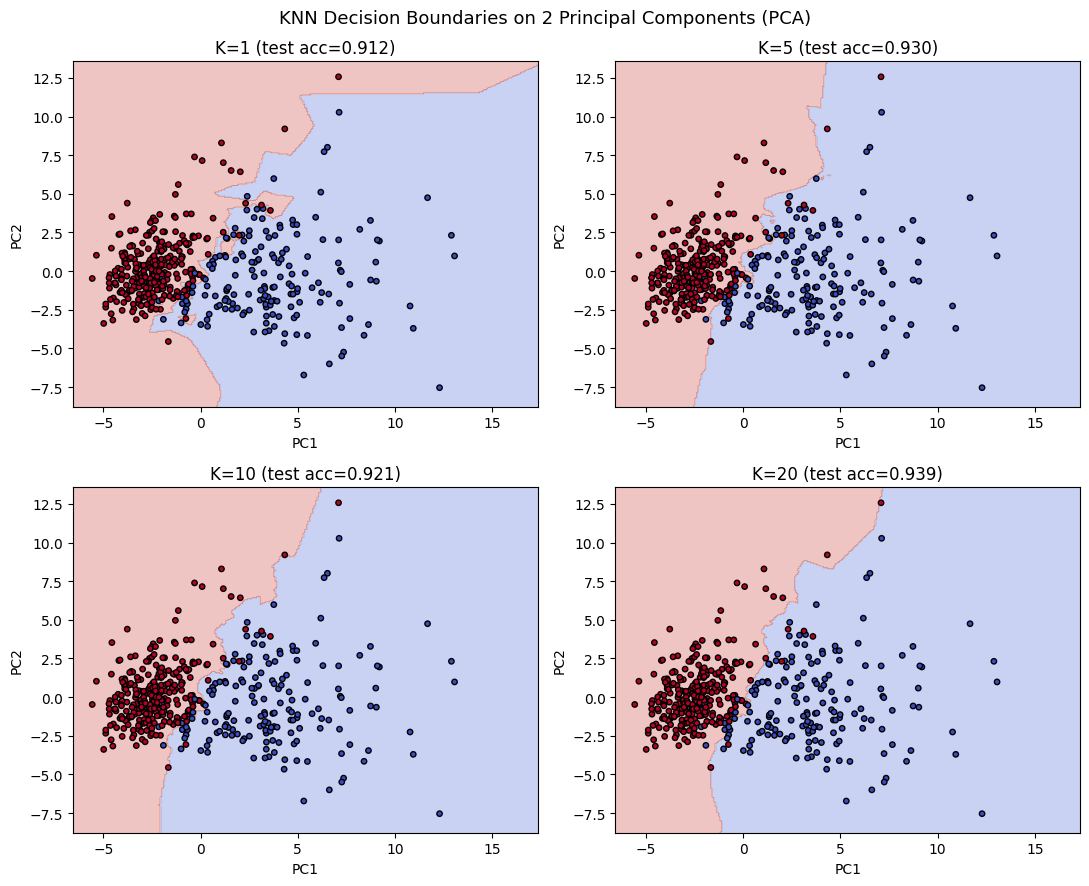

In [ ]:
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_scaled)
print("Explained variance ratio (2 PCs):", pca.explained_variance_ratio_, "sum=", pca.explained_variance_ratio_.sum())

Xtr2, Xte2, ytr2, yte2 = train_test_split(X2, y, test_size=0.20, random_state=42, stratify=y)

k_values = [1, 5, 10, 20]
fig, axes = plt.subplots(2, 2, figsize=(11,9))
x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

for ax, k in zip(axes.ravel(), k_values):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(Xtr2, ytr2)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(Xtr2[:,0], Xtr2[:,1], c=ytr2, cmap='coolwarm', edgecolor='k', s=15)
    acc = accuracy_score(yte2, model.predict(Xte2))
    ax.set_title(f'K={k} (test acc={acc:.3f})')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('KNN Decision Boundaries on 2 Principal Components (PCA)', fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** As K increases, the decision boundary becomes progressively smoother: K=1 gives a jagged, highly flexible boundary that follows individual points (low bias, high variance — overfitting risk). K=20 gives a much smoother, more generalized boundary (higher bias, lower variance). This illustrates the classic bias-variance trade-off governed by K. (Accuracy here is lower than the full 30-feature model since only ~63% of variance is captured by 2 principal components.)

## Task 4: Cross Validation
Apply 5-fold and 10-fold K-Fold Cross Validation across the same K range and compare with the train-test split results.

In [ ]:
cv5_means, cv10_means = [], []
for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    cv5 = cross_val_score(model, X_scaled, y, cv=KFold(n_splits=5, shuffle=True, random_state=42))
    cv10 = cross_val_score(model, X_scaled, y, cv=KFold(n_splits=10, shuffle=True, random_state=42))
    cv5_means.append(cv5.mean())
    cv10_means.append(cv10.mean())
    print(f"K={k:2d}  5-fold mean acc={cv5.mean():.4f}  10-fold mean acc={cv10.mean():.4f}")

best5_k = list(k_range)[int(np.argmax(cv5_means))]
best10_k = list(k_range)[int(np.argmax(cv10_means))]
print(f"\nBest K (5-fold CV)  = {best5_k}, acc={max(cv5_means):.4f}")
print(f"Best K (10-fold CV) = {best10_k}, acc={max(cv10_means):.4f}")

K=16  5-fold mean acc=0.9543  10-fold mean acc=0.9595
K=17  5-fold mean acc=0.9543  10-fold mean acc=0.9560
K=18  5-fold mean acc=0.9578  10-fold mean acc=0.9595
K=19  5-fold mean acc=0.9560  10-fold mean acc=0.9560
K=20  5-fold mean acc=0.9560  10-fold mean acc=0.9577


K=21  5-fold mean acc=0.9543  10-fold mean acc=0.9542
K=22  5-fold mean acc=0.9543  10-fold mean acc=0.9577
K=23  5-fold mean acc=0.9543  10-fold mean acc=0.9542
K=24  5-fold mean acc=0.9560  10-fold mean acc=0.9542
K=25  5-fold mean acc=0.9525  10-fold mean acc=0.9542


K=26  5-fold mean acc=0.9525  10-fold mean acc=0.9542

Best K (5-fold CV)  = 18, acc=0.9578
Best K (10-fold CV) = 16, acc=0.9595


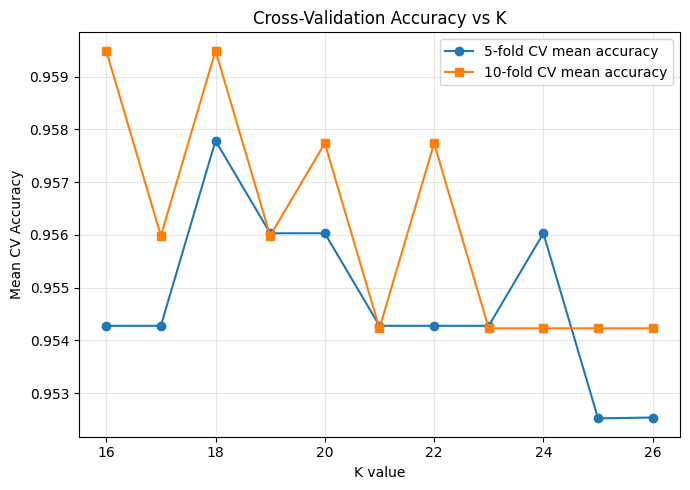

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(list(k_range), cv5_means, marker='o', label='5-fold CV mean accuracy')
plt.plot(list(k_range), cv10_means, marker='s', label='10-fold CV mean accuracy')
plt.xlabel('K value'); plt.ylabel('Mean CV Accuracy')
plt.title('Cross-Validation Accuracy vs K')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

**Best K overall:** Combining the heuristic (K=21), the train-test sweep (best K=18) and cross-validation (best ≈ K=18/16, both near 18), **K = 18** is selected as the final model K — it performs best or near-best under every validation method. Cross-validation results (95.3%–96.0%) are close to, but slightly more conservative than, the single train-test split results, since CV averages performance over multiple folds instead of relying on one split.

## Task 5: Classification Evaluation (Final Model, K = 18)
Evaluate the final model with Accuracy, Precision, Recall, F1, Confusion Matrix and ROC-AUC.

In [ ]:
BEST_K = 18
model = KNeighborsClassifier(n_neighbors=BEST_K)
model.fit(Xtr, ytr)
ypred = model.predict(Xte)
yproba = model.predict_proba(Xte)[:,1]

acc = accuracy_score(yte, ypred)
prec = precision_score(yte, ypred)
rec = recall_score(yte, ypred)
f1 = f1_score(yte, ypred)
cm = confusion_matrix(yte, ypred)
auc = roc_auc_score(yte, yproba)

print(f"Final Model: KNN with K={BEST_K}")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")
print("Confusion Matrix:\n", cm)

Final Model: KNN with K=18
Accuracy : 0.9825
Precision: 0.9730
Recall   : 1.0000
F1 Score : 0.9863
ROC-AUC  : 0.9924
Confusion Matrix:
 [[40  2]
 [ 0 72]]


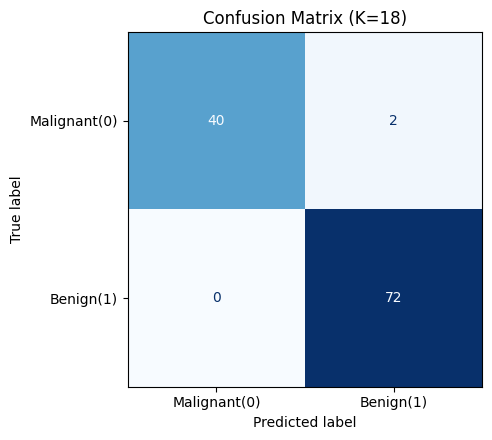

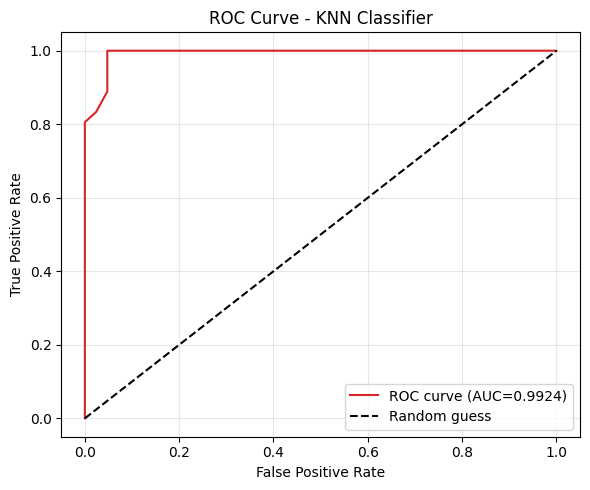

In [ ]:
fig, ax = plt.subplots(figsize=(5,4.5))
ConfusionMatrixDisplay(cm, display_labels=['Malignant(0)','Benign(1)']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix (K={BEST_K})')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(yte, yproba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='#d62728', label=f'ROC curve (AUC={auc:.4f})')
plt.plot([0,1],[0,1],'k--', label='Random guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Classifier')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

**Observation:** The model achieves zero false negatives on this test split (recall = 1.0) — clinically the most important property, since a false negative means a malignant case is missed. The 2 false positives are a far safer error (benign flagged for further testing) than a missed cancer diagnosis.

## Task 6: Comparative Study with Regression (Lab 3 Integration)

Reference: Lab 3 (Linear Regression) evaluated MAE, MSE, RMSE and R² Score. For direct comparison, an illustrative Linear Regression model is built on the same dataset family here (predicting the continuous feature `mean radius` from the remaining 29 features), reproducing the Lab 3 workflow.

In [ ]:
target_col = 'mean radius'
Xr = df.drop(columns=[target_col, 'target']).values
yr = df[target_col].values

scaler_r = StandardScaler()
Xr_scaled = scaler_r.fit_transform(Xr)

Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(Xr_scaled, yr, test_size=0.20, random_state=42)
lr = LinearRegression()
lr.fit(Xtr_r, ytr_r)
pred_r = lr.predict(Xte_r)

mae = mean_absolute_error(yte_r, pred_r)
mse = mean_squared_error(yte_r, pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(yte_r, pred_r)

print("Illustrative Linear Regression (predicting 'mean radius'), representative of Lab 3:")
print(f"MAE  = {mae:.4f}")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R2   = {r2:.4f}")

Illustrative Linear Regression (predicting 'mean radius'), representative of Lab 3:
MAE  = 0.0445
MSE  = 0.0048
RMSE = 0.0692
R2   = 0.9996


### Regression vs Classification Metrics

| Aspect | Regression (Lab 3) | Classification (this lab) |
|---|---|---|
| What is measured | Magnitude of numeric prediction error | Correctness of a discrete decision (class label) |
| Key metrics | MAE, MSE, RMSE, R² | Accuracy, Precision, Recall, F1, ROC-AUC |
| Error scale | Continuous, unbounded (same units as target) | Bounded (0–1), based on counts of correct/incorrect labels |
| Ideal value | Error metrics → 0, R² → 1 | All metrics → 1 (100%) |

**R² Score vs Accuracy:** R² measures the proportion of variance in a continuous target explained by the model (can even go negative for a poor fit). Accuracy measures the fraction of exactly correct discrete predictions. Both summarize "how good is the model" in one number, but R² is about explained variance while accuracy is about correct classification counts; accuracy has no notion of partial correctness the way regression does.

**RMSE vs F1 Score:** RMSE penalizes large numeric errors heavily (via squaring) and reports results in the target's own units — an error-magnitude measure. F1 is the harmonic mean of precision and recall, measuring the balance between false positives and false negatives — a correctness/quality measure, not a distance measure. Lower RMSE is better; higher F1 is better; they are not on comparable scales.

**MAE vs Confusion Matrix:** MAE collapses all errors into a single average absolute-error number. A confusion matrix instead breaks down every outcome type (TP, TN, FP, FN) — essential in classification because different error types (missing a cancer case vs a false alarm) carry very different real-world costs, a distinction MAE-style averaging cannot express.

**Continuous vs Classification Evaluation Logic:** Regression evaluates "how far" a numeric prediction is from the truth — every unit of deviation matters equally. Classification evaluates "was the decision right or wrong" — no partial credit, but different mistake types (false positive vs false negative) can carry very different consequences, hence the richer toolkit (precision, recall, F1, ROC-AUC) instead of a single averaged error.

### Inference
Regression metrics (MAE, MSE, RMSE, R²) quantify how far off, on average, a continuous prediction is from the true numeric value — they measure error magnitude and variance explained. Classification metrics (accuracy, precision, recall, F1, ROC-AUC) quantify how often a discrete decision was correct, and distinguish between types of correctness/error (true/false positives and negatives). **Accuracy alone is insufficient in medical diagnosis** because the dataset is imbalanced (212 malignant vs 357 benign) and errors are asymmetric: a model predicting "benign" for borderline cases can score high accuracy while missing real cancers. **Recall (sensitivity) is more relevant in healthcare** because it directly measures the fraction of actual malignant cases correctly caught — minimizing false negatives is the clinical priority, since a missed cancer is far costlier than a false alarm. **ROC-AUC** is more informative than accuracy because it evaluates class separability across all decision thresholds, not just one fixed cutoff, making it robust to class imbalance. Overall: regression evaluation minimizes continuous error distance, while classification evaluation maximizes correct, risk-aware decisions — two related but fundamentally different evaluation frameworks.

## Task 7: Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**
It does not build an explicit model during training — it simply stores the training data. Computation (distance calculation, voting) is deferred until prediction time, unlike "eager" learners such as linear regression or decision trees.

**2. Why is feature scaling required in KNN?**
KNN relies directly on distance between feature vectors. Features with larger numeric ranges would dominate the distance metric regardless of actual predictive importance. Scaling puts all features on a comparable scale.

**3. Explain heuristic K selection using the √n rule.**
K = √n (n = number of training samples) is a rule-of-thumb starting point balancing bias and variance without exhaustive search, usually rounded to the nearest odd integer to avoid tied votes in binary classification. It is only a starting point — true optimal K is found via experimentation/cross-validation.

**4. Why is cross-validation more reliable than a single train-test split?**
A single split's performance estimate depends heavily on which samples land in the test set — it can be optimistic or pessimistic by chance. Cross-validation averages results across multiple folds, giving a lower-variance, more stable estimate and better use of available data.

**5. How does K affect the bias-variance trade-off?**
Small K (e.g. K=1) is highly flexible and sensitive to individual points — low bias, high variance (overfitting). Large K smooths predictions over many neighbours — higher bias, lower variance (underfitting risk). Optimal K balances the two.

**6. Why is recall more important than accuracy in cancer prediction?**
A false negative (predicting benign when actually malignant) is far more dangerous than a false positive, since it delays treatment for an actual cancer patient. Recall directly measures the fraction of malignant cases correctly identified — a more clinically meaningful metric than overall accuracy, which can look good even while missing malignant cases under class imbalance.

**7. What is the limitation of very large K values?**
Very large K oversmooths the decision boundary, incorporating points from the opposite/majority class into the neighbourhood and causing the model to default toward the majority class, losing sensitivity to local patterns. This increases bias, can hurt minority-class performance, and increases per-prediction computational cost — eventually approaching "always predict the majority class" as K → n.

## Expected Outcome
- Understanding of the KNN algorithm and distance-based learning.
- Ability to tune K using heuristic reasoning combined with empirical validation.
- Practical knowledge of k-fold cross-validation.
- Interpretation of ROC-AUC in a medical classification context.
- A strong conceptual link between regression and classification evaluation metrics.

## Conclusion
The heuristic rule (K = √n) gave an initial estimate of K = 21, but empirical validation via both the train-test sweep and 5/10-fold cross-validation converged on **K = 18** as the optimal choice, showing the value of combining heuristics with data-driven validation. Across the three split ratios tested, accuracy ranged from 94.7% to 98.3%; larger training sets produced more stable estimates, while smaller test sets (as in 90:10) produced less reliable, higher-variance accuracy readings. The final KNN model (K = 18) achieved strong performance on the held-out test set: accuracy 0.9825, precision 0.9730, recall 1.0000, F1 0.9863, and ROC-AUC 0.9924, with zero false negatives — the most clinically important result. Comparing with Lab 3's regression metrics (MAE, MSE, RMSE, R²), this lab confirms that regression evaluation is fundamentally about measuring continuous error magnitude, while classification evaluation is about measuring the correctness and risk-profile of discrete decisions. In a medical diagnosis setting, recall and ROC-AUC are more trustworthy indicators of true model quality than plain accuracy, since they explicitly account for the asymmetric cost of missing a cancer diagnosis versus raising a false alarm.

## Result Stability Check
To confirm the final model was not the result of a single lucky split, K = 18 is re-evaluated across 3 different random seeds for the train-test split, and cross-validation is re-run across 3 different shuffle seeds.

In [ ]:
print("=== Re-run with 3 different random seeds ===")
for seed in [0, 42, 123]:
    Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(X_scaled, y, test_size=0.20, random_state=seed, stratify=y)
    model_s = KNeighborsClassifier(n_neighbors=18)
    model_s.fit(Xtr_s, ytr_s)
    pred_s = model_s.predict(Xte_s)
    proba_s = model_s.predict_proba(Xte_s)[:,1]
    print(f"seed={seed}: acc={accuracy_score(yte_s,pred_s):.4f}, f1={f1_score(yte_s,pred_s):.4f}, auc={roc_auc_score(yte_s,proba_s):.4f}")

print("\n=== Re-run CV with different shuffle seeds ===")
for seed in [1, 7, 99]:
    model_s = KNeighborsClassifier(n_neighbors=18)
    scores = cross_val_score(model_s, X_scaled, y, cv=KFold(n_splits=5, shuffle=True, random_state=seed))
    print(f"CV seed={seed}: mean acc={scores.mean():.4f}, std={scores.std():.4f}")

print("\nResults remain consistently in the 95-98% accuracy range with AUC consistently above 0.98,")
print("confirming the model is stable and not an artifact of a single split.")

=== Re-run with 3 different random seeds ===
seed=0: acc=0.9561, f1=0.9660, auc=0.9881
seed=42: acc=0.9825, f1=0.9863, auc=0.9924
seed=123: acc=0.9825, f1=0.9861, auc=0.9988

=== Re-run CV with different shuffle seeds ===
CV seed=1: mean acc=0.9526, std=0.0152
CV seed=7: mean acc=0.9544, std=0.0224
CV seed=99: mean acc=0.9631, std=0.0195

Results remain consistently in the 95-98% accuracy range with AUC consistently above 0.98,
confirming the model is stable and not an artifact of a single split.
